# Hugging Face DPO Demo: The Gen Academy Brand Voice

**Use case:** fine-tune a model to prefer The Gen Academy's practical, energetic, accessible, builder-focused brand voice.

**What this is:** an LLM DPO demo. We start with an instruction-tuned causal language model, give it preference pairs, and train a small LoRA adapter so the LLM assigns higher likelihood to the on-brand answer than the off-brand answer.

**What this is not:** it is not supervised fine-tuning on a single target answer, and it is not training a separate reward model. DPO directly updates the LLM from `prompt`, `chosen`, and `rejected` examples.

**Important dataset note:** the source dataset includes a `preference_reason` field so the workshop audience can understand the label. That reason is not passed to DPO training. The trainer only uses the prompt, chosen response, and rejected response.

The comparison uses:

1. Training loss and reward-margin curves.
2. Base vs tuned preference-margin charts on held-out examples.
3. A concrete before/after preference example where the tuned adapter moves toward the on-brand answer.


![Diagram](./images/01_img.png)

## 1. Setup


In [13]:
import gc
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def load_hf_token(env_path=Path(".env")):
    """Load HF_TOKEN from a .env file into the environment.

    Uses python-dotenv if it is installed, otherwise falls back to a small
    manual parser so no extra dependency is required. When a real token is
    found it also sets HUGGING_FACE_HUB_TOKEN, the alias the Hub libraries read.
    """
    try:
        from dotenv import load_dotenv

        load_dotenv(env_path)
    except ModuleNotFoundError:
        if env_path.exists():
            for line in env_path.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, _, value = line.partition("=")
                os.environ.setdefault(key.strip(), value.strip().strip("'\""))

    token = os.environ.get("HF_TOKEN", "")
    if token and token != "your_hugging_face_token_here":
        os.environ["HUGGING_FACE_HUB_TOKEN"] = token
        print("HF token loaded from environment.")
    else:
        print("No HF token set. Add your token to .env (HF_TOKEN=...) to enable authenticated requests.")
    return token


HF_TOKEN = load_hf_token()

SOURCE_DATA_PATH = Path("data/brand_voice_preferences.jsonl")
TRL_DATA_PATH = Path("data/brand_voice_trl_dpo.jsonl")
TRL_TRAIN_PATH = Path("data/brand_voice_trl_dpo_train.jsonl")
TRL_EVAL_PATH = Path("data/brand_voice_trl_dpo_eval.jsonl")


HF token loaded from environment.


## 2. Inspect the source dataset

The source JSONL is the human-readable version of the demo data. Each row has:

- `prompt`: the task the model should answer.
- `chosen`: the preferred Gen Academy-style response.
- `rejected`: the less preferred response.
- `preference_reason`: a plain-English explanation of why the chosen answer is better.
- `split` and `category`: metadata for evaluation and demo navigation.

The `preference_reason` is useful for explaining the dataset live, but it is intentionally not used by the DPO trainer.


![Diagram](./images/02_img.png)

In [14]:
# This is the readable source dataset. It includes explanation metadata for humans.
source_rows = [
    json.loads(line)
    for line in SOURCE_DATA_PATH.read_text(encoding="utf-8").splitlines()
    if line.strip()
]
source_df = pd.DataFrame(source_rows)

print(f"Loaded {len(source_df)} preference pairs")
print(source_df["split"].value_counts().to_string())
source_df.groupby(["split", "category"]).size().unstack(fill_value=0)


Loaded 80 preference pairs
split
train    72
eval      8


category,course_page_copy,email_copy,faq_answer,mission_copy,partner_announcement,product_microcopy,program_update,project_feedback,social_post,workshop_promo
split,,,,,,,,,,
eval,1,0,1,1,1,1,1,0,1,1
train,7,8,7,7,7,7,7,8,7,7


In [15]:
def show_pair(row):
    print(f"{row['id']} | {row['split']} | {row['category']}")
    print("\nTASK")
    print(row["prompt"])
    print("\nCHOSEN")
    print(row["chosen"])
    print("\nREJECTED")
    print(row["rejected"])
    print("\nWHY THIS PAIR IS LABELED THIS WAY")
    print(row["preference_reason"])
    print("\nDPO USES")
    print("prompt + chosen + rejected")
    print("\nDPO DOES NOT USE")
    print("preference_reason, category, or split")


show_pair(source_df.iloc[0])


GA-DPO-001 | eval | workshop_promo

TASK
Write a short promo for a Agentic AI workshop.

CHOSEN
Join The Gen Academy for a hands-on Agentic AI workshop. You will design agent workflows, choose the right tools, and evaluate reliability, with practical exercises you can reuse after the session.

REJECTED
Unlock the future of Agentic AI with a revolutionary masterclass that will transform your career overnight. Seats are limited, so do not miss this once-in-a-lifetime opportunity!

WHY THIS PAIR IS LABELED THIS WAY
Chosen is practical, specific, and outcome-focused. Rejected is hype-heavy and over-promises.

DPO USES
prompt + chosen + rejected

DPO DOES NOT USE
preference_reason, category, or split


## 3. Convert to TRL DPO format

TRL's `DPOTrainer` expects each example to contain:

- `prompt`: the conversation context.
- `chosen`: the preferred assistant completion.
- `rejected`: the less preferred assistant completion.

The notebook keeps `id`, `split`, and `category` so we can inspect results later. The `preference_reason` field is dropped before training because DPO should learn from the preference comparison, not from the written explanation.


In [16]:
trl_rows = [json.loads(line) for line in TRL_DATA_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
train_rows = [json.loads(line) for line in TRL_TRAIN_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
eval_rows = [json.loads(line) for line in TRL_EVAL_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]

for row in trl_rows:
    assert "prompt" in row and "chosen" in row and "rejected" in row
    assert "preference_reason" not in row
    assert row["chosen"][-1]["role"] == "assistant"
    assert row["rejected"][-1]["role"] == "assistant"

print(f"Validated {len(trl_rows)} TRL rows")
print(f"Train rows: {len(train_rows)}")
print(f"Eval rows:  {len(eval_rows)}")
print("Confirmed: preference_reason is not present in the DPO training rows.")
print(json.dumps(trl_rows[0], indent=2)[:1200])


Validated 80 TRL rows
Train rows: 72
Eval rows:  8
Confirmed: preference_reason is not present in the DPO training rows.
{
  "id": "GA-DPO-001",
  "split": "eval",
  "category": "workshop_promo",
  "prompt": [
    {
      "role": "system",
      "content": "You write for The Gen Academy, an AI education company. Match the brand voice: practical, energetic, credible, accessible, community-driven, and outcome-focused. Make AI feel buildable, not abstract. Emphasize real systems, real projects, and useful skills. Cut through hype without sounding dry. Avoid corporate jargon, vague inspiration, fear-based urgency, empty superlatives, emojis, excessive exclamation, and claims that feel too broad or guaranteed."
    },
    {
      "role": "user",
      "content": "Write a short promo for a Agentic AI workshop."
    }
  ],
  "chosen": [
    {
      "role": "assistant",
      "content": "Join The Gen Academy for a hands-on Agentic AI workshop. You will design agent workflows, choose the right 

## 4. Load datasets and configure DPO

This demo uses `HuggingFaceTB/SmolLM2-135M-Instruct` so the whole run can fit on a laptop. The same DPO structure scales to larger LLMs.

Key settings:

- `beta`: controls how strongly DPO pushes away from the rejected answer relative to the base model.
- LoRA settings: train a lightweight adapter instead of updating every model weight.
- train/eval split: train on 72 pairs, then score the 8 held-out pairs for a cleaner before/after.


In [17]:
from datasets import load_dataset

train_dataset = load_dataset("json", data_files=str(TRL_TRAIN_PATH), split="train")
eval_dataset = load_dataset("json", data_files=str(TRL_EVAL_PATH), split="train")
print(train_dataset)
print(eval_dataset)


Dataset({
    features: ['id', 'split', 'category', 'prompt', 'chosen', 'rejected'],
    num_rows: 72
})
Dataset({
    features: ['id', 'split', 'category', 'prompt', 'chosen', 'rejected'],
    num_rows: 8
})


In [7]:
# This is the base LLM. DPO will update a LoRA adapter on top of this model.
BASE_MODEL = os.environ.get("HF_DPO_BASE_MODEL", "HuggingFaceTB/SmolLM2-135M-Instruct")
OUTPUT_DIR = "outputs/gen-academy-brand-voice-hf-dpo"

# These settings are deliberately small for a live workshop run.
# A production run would use more data, stronger evaluation, and likely a larger base model.
dpo_settings = {
    "base_model": BASE_MODEL,
    "output_dir": OUTPUT_DIR,
    "beta": 0.1,
    "learning_rate": 2e-5,
    "num_train_epochs": 3,
    "per_device_train_batch_size": 1,
    "gradient_accumulation_steps": 8,
    "max_length": 1024,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
}

dpo_settings


{'base_model': 'HuggingFaceTB/SmolLM2-135M-Instruct',
 'output_dir': 'outputs/gen-academy-brand-voice-hf-dpo',
 'beta': 0.1,
 'learning_rate': 2e-05,
 'num_train_epochs': 3,
 'per_device_train_batch_size': 1,
 'gradient_accumulation_steps': 8,
 'max_length': 1024,
 'lora_r': 16,
 'lora_alpha': 32,
 'lora_dropout': 0.05}

## 5. Before DPO: score preference pairs

To make the before/after concrete, we score both completions instead of relying on free-form generations.

For each pair, the notebook computes:

`margin = logprob(chosen response) - logprob(rejected response)`

- Positive margin: the model already prefers the Gen Academy-style answer.
- Negative margin: the model prefers the off-brand answer.
- After DPO, we want the margin to move upward.


![Diagram](./images/03_img.png)

In [18]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer


def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()


def load_base_model():
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    model = AutoModelForCausalLM.from_pretrained(BASE_MODEL, torch_dtype=torch.float32)
    model.eval()
    if torch.backends.mps.is_available():
        model.to("mps")
    return model, tokenizer


def completion_logprob(model, tokenizer, prompt_messages, completion_text):
    # Convert chat messages into the exact text format expected by the base LLM.
    prompt_text = tokenizer.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
    full_text = prompt_text + completion_text + (tokenizer.eos_token or "")
    prompt_ids = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False)["input_ids"]
    full = tokenizer(full_text, return_tensors="pt", add_special_tokens=False)
    input_ids = full["input_ids"]
    if torch.backends.mps.is_available():
        input_ids = input_ids.to("mps")
    with torch.no_grad():
        logits = model(input_ids).logits
    labels = input_ids[:, 1:]
    logprobs = torch.log_softmax(logits[:, :-1, :], dim=-1)
    token_logprobs = logprobs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)

    # Only score the assistant completion tokens, not the prompt tokens.
    start = max(prompt_ids.shape[-1] - 1, 0)
    return float(token_logprobs[:, start:].sum().detach().cpu())


def score_pairs(model, tokenizer, rows, label):
    scored = []
    for row in rows:
        chosen = row["chosen"][-1]["content"]
        rejected = row["rejected"][-1]["content"]
        chosen_logp = completion_logprob(model, tokenizer, row["prompt"], chosen)
        rejected_logp = completion_logprob(model, tokenizer, row["prompt"], rejected)
        # The preference margin is the live-demo before/after metric.
        # Higher means the LLM is more likely to produce the chosen answer than the rejected one.
        scored.append(
            {
                "model": label,
                "id": row["id"],
                "split": row["split"],
                "category": row["category"],
                "chosen_logp": chosen_logp,
                "rejected_logp": rejected_logp,
                "margin": chosen_logp - rejected_logp,
                "prefers_chosen": chosen_logp > rejected_logp,
            }
        )
    return pd.DataFrame(scored)


base_model, tokenizer = load_base_model()
base_all_scores = score_pairs(base_model, tokenizer, trl_rows, "base")
base_eval_scores = base_all_scores[base_all_scores["split"] == "eval"].copy()
display(base_eval_scores[["id", "category", "margin", "prefers_chosen"]])
print("Base eval win rate:", f"{base_eval_scores['prefers_chosen'].mean():.0%}")
del base_model
clear_memory()


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

,id,category,margin,prefers_chosen
0,GA-DPO-001,workshop_promo,-18.999649,False
10,GA-DPO-011,program_update,-93.528786,False
20,GA-DPO-021,mission_copy,-9.451004,False
30,GA-DPO-031,social_post,-10.070015,False
40,GA-DPO-041,product_microcopy,-1.145981,False
50,GA-DPO-051,faq_answer,-47.124077,False
60,GA-DPO-061,partner_announcement,-26.496094,False
70,GA-DPO-071,course_page_copy,-32.566444,False


Base eval win rate: 0%


## 6. Train the DPO adapter

This is the actual LLM DPO step. `DPOTrainer` compares each chosen/rejected pair under the current LLM and updates the LoRA adapter so chosen responses become more likely relative to rejected responses.

The cell trains only if `outputs/gen-academy-brand-voice-hf-dpo` does not exist. That keeps the notebook ready for live use: it can show the already-trained adapter without retraining every time.


![Diagram](./images/04_img.png)

In [20]:
# If the adapter already exists, skip retraining and reuse it for the visual before/after.
RUN_HF_DPO_TRAINING = not Path(OUTPUT_DIR).exists()

if RUN_HF_DPO_TRAINING:
    import shutil
    from peft import LoraConfig
    from trl import DPOConfig, DPOTrainer

    if Path(OUTPUT_DIR).exists():
        shutil.rmtree(OUTPUT_DIR)

    # DPOConfig tells TRL how strongly to optimize preference separation.
    training_args = DPOConfig(
        output_dir=OUTPUT_DIR,
        beta=dpo_settings["beta"],
        learning_rate=dpo_settings["learning_rate"],
        num_train_epochs=dpo_settings["num_train_epochs"],
        per_device_train_batch_size=dpo_settings["per_device_train_batch_size"],
        gradient_accumulation_steps=dpo_settings["gradient_accumulation_steps"],
        max_length=dpo_settings["max_length"],
        logging_steps=2,
        save_strategy="epoch",
        model_init_kwargs={"torch_dtype": torch.float32},
    )

    # LoRA keeps the demo lightweight by training adapter weights instead of the full LLM.
    peft_config = LoraConfig(
        r=dpo_settings["lora_r"],
        lora_alpha=dpo_settings["lora_alpha"],
        lora_dropout=dpo_settings["lora_dropout"],
        target_modules="all-linear",
        task_type="CAUSAL_LM",
    )

    # DPOTrainer consumes prompt/chosen/rejected rows. It does not consume preference_reason.
    trainer = DPOTrainer(
        model=BASE_MODEL,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        peft_config=peft_config,
    )
    trainer.train()
    trainer.save_model(OUTPUT_DIR)
    del trainer
    clear_memory()
else:
    print(f"Adapter already exists at {OUTPUT_DIR}. Delete that folder to retrain from scratch.")


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

/Users/arvindna/Desktop/DPO/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
2,0.690118
4,0.687478
6,0.682532
8,0.683580
10,0.672307
12,0.667810
14,0.660333
16,0.645584
18,0.648299
20,0.648320


/Users/arvindna/Desktop/DPO/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/arvindna/Desktop/DPO/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


## 7. Training curves

These plots turn the DPO math into something easier to narrate.

- DPO loss should generally move down.
- Reward margin should generally move up, meaning the trainer is separating chosen answers from rejected answers.
- Reward accuracy shows how often the chosen response receives the higher implicit reward in a batch.


![Diagram](./images/06_img.png)

,step,loss,rewards/margins,rewards/accuracies
0,2,0.690118,0.006394,0.5625
1,4,0.687478,0.011825,0.6250
2,6,0.682532,0.021611,0.8125
3,8,0.683580,0.019443,0.7500
4,10,0.672307,0.042517,0.9375
5,12,0.667810,0.051631,0.9375
6,14,0.660333,0.066994,1.0000
7,16,0.645584,0.097836,1.0000
8,18,0.648299,0.092351,1.0000
9,20,0.648320,0.092321,1.0000


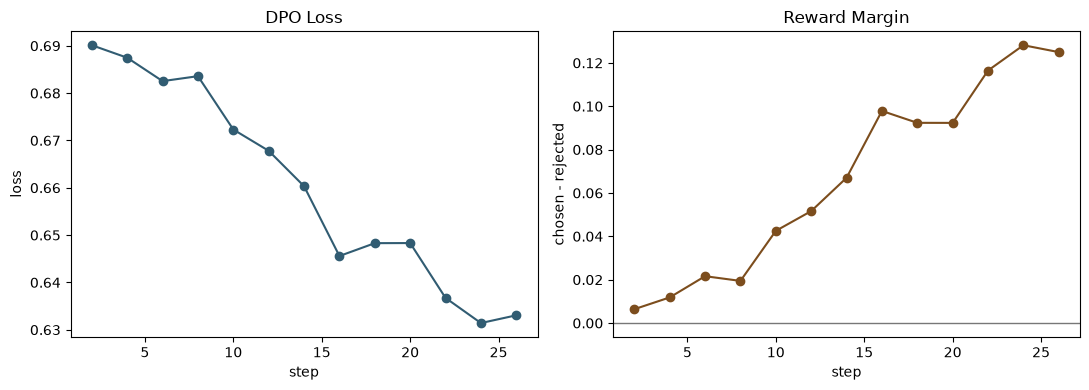

In [21]:
trainer_states = sorted(
    Path(OUTPUT_DIR).glob("checkpoint-*/trainer_state.json"),
    key=lambda path: int(path.parent.name.split("-")[-1]),
)
trainer_state_path = trainer_states[-1] if trainer_states else None
if trainer_state_path:
    trainer_state = json.loads(trainer_state_path.read_text())
    logs = pd.DataFrame(trainer_state["log_history"])
    metric_logs = logs[logs["loss"].notna()].copy()
    display(metric_logs[["step", "loss", "rewards/margins", "rewards/accuracies"]])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(metric_logs["step"], metric_logs["loss"], marker="o", color="#315c72")
    axes[0].set_title("DPO Loss")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("loss")
    axes[1].plot(metric_logs["step"], metric_logs["rewards/margins"], marker="o", color="#7c4d1d")
    axes[1].axhline(0, color="#777", linewidth=1)
    axes[1].set_title("Reward Margin")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("chosen - rejected")
    plt.tight_layout()
else:
    print("No trainer_state.json found yet. Run training first.")


## 8. After DPO: score the same pairs again

This cell reloads the base LLM, attaches the trained LoRA adapter, and repeats the exact same scoring function.

The important comparison is not just whether the tuned model wins every pair. For a small model and tiny dataset, the clearer signal is whether the preference margin moves in the right direction on train and held-out examples.


![Diagram](./images/05_img.png)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

DPO moved the preference margin toward the chosen response on 80/80 total pairs and 8/8 eval pairs.


,scope,pairs,base_win_rate,tuned_win_rate,avg_base_margin,avg_tuned_margin,avg_margin_change,pairs_moved_toward_chosen,pct_moved_toward_chosen
0,eval,8,0.0000,0.125,-29.922756,-26.263728,3.659028,8,1.0
1,all_pairs,80,0.1375,0.175,-33.049116,-29.229070,3.820046,80,1.0


,id,category,margin_base,margin_tuned,margin_change,prefers_chosen_base,prefers_chosen_tuned
0,GA-DPO-001,workshop_promo,-18.999649,-12.697289,6.302361,False,False
10,GA-DPO-011,program_update,-93.528786,-88.400055,5.128731,False,False
20,GA-DPO-021,mission_copy,-9.451004,-6.910980,2.540024,False,False
30,GA-DPO-031,social_post,-10.070015,-6.906715,3.163300,False,False
40,GA-DPO-041,product_microcopy,-1.145981,1.124214,2.270195,False,True
50,GA-DPO-051,faq_answer,-47.124077,-43.094315,4.029762,False,False
60,GA-DPO-061,partner_announcement,-26.496094,-23.700752,2.795341,False,False
70,GA-DPO-071,course_page_copy,-32.566444,-29.523933,3.042511,False,False


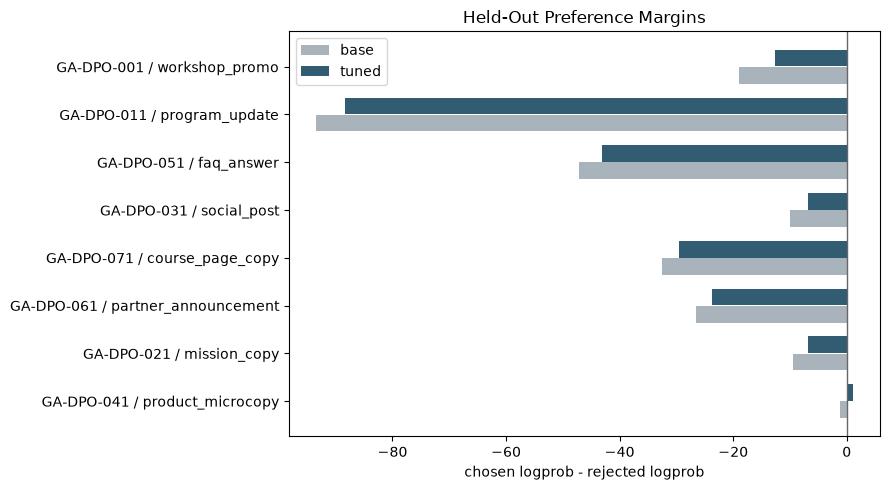

In [22]:
from peft import PeftModel

# Load the same base LLM, then attach the DPO-trained LoRA adapter.
tuned_base, tokenizer = load_base_model()
tuned_model = PeftModel.from_pretrained(tuned_base, OUTPUT_DIR)
tuned_model.eval()
if torch.backends.mps.is_available():
    tuned_model.to("mps")

# Score the exact same chosen/rejected completions again after DPO.
tuned_all_scores = score_pairs(tuned_model, tokenizer, trl_rows, "tuned")
comparison_all = base_all_scores.merge(
    tuned_all_scores,
    on=["id", "split", "category"],
    suffixes=("_base", "_tuned"),
)
comparison_all["margin_change"] = comparison_all["margin_tuned"] - comparison_all["margin_base"]
comparison_eval = comparison_all[comparison_all["split"] == "eval"].copy()

def summarize(scope, frame):
    return {
        "scope": scope,
        "pairs": len(frame),
        "base_win_rate": frame["prefers_chosen_base"].mean(),
        "tuned_win_rate": frame["prefers_chosen_tuned"].mean(),
        "avg_base_margin": frame["margin_base"].mean(),
        "avg_tuned_margin": frame["margin_tuned"].mean(),
        "avg_margin_change": frame["margin_change"].mean(),
        "pairs_moved_toward_chosen": int((frame["margin_change"] > 0).sum()),
        "pct_moved_toward_chosen": (frame["margin_change"] > 0).mean(),
    }

# margin_change > 0 means DPO moved the LLM toward the Gen Academy-style answer.
summary = pd.DataFrame([summarize("eval", comparison_eval), summarize("all_pairs", comparison_all)])
print(
    f"DPO moved the preference margin toward the chosen response on "
    f"{int((comparison_all['margin_change'] > 0).sum())}/{len(comparison_all)} total pairs "
    f"and {int((comparison_eval['margin_change'] > 0).sum())}/{len(comparison_eval)} eval pairs."
)
display(summary)
display(comparison_eval[["id", "category", "margin_base", "margin_tuned", "margin_change", "prefers_chosen_base", "prefers_chosen_tuned"]])

plot_df = comparison_eval.sort_values("margin_change")
fig, ax = plt.subplots(figsize=(9, 5))
y = range(len(plot_df))
ax.barh([i - 0.18 for i in y], plot_df["margin_base"], height=0.35, label="base", color="#a9b3bb")
ax.barh([i + 0.18 for i in y], plot_df["margin_tuned"], height=0.35, label="tuned", color="#315c72")
ax.axvline(0, color="#666", linewidth=1)
ax.set_yticks(list(y))
ax.set_yticklabels(plot_df["id"] + " / " + plot_df["category"])
ax.set_title("Held-Out Preference Margins")
ax.set_xlabel("chosen logprob - rejected logprob")
ax.legend()
plt.tight_layout()


## 9. Concrete before/after example

The notebook automatically selects a pair where the base model preferred the rejected response and the tuned adapter prefers the chosen response. If no pair fully flips, it selects the pair with the largest positive margin shift.

![Diagram](./images/07_img.png)

Concrete before/after example
Example: GA-DPO-056 / faq_answer
Base margin:  -1.74
Tuned margin: 2.20
Change:       3.94

TASK
Answer this FAQ for The Gen Academy: Is there a capstone?

ON-BRAND CHOSEN
Longer programs include a capstone so you can apply the material to an end-to-end AI workflow.

OFF-BRAND REJECTED
Absolutely. Our world-class, future-ready AI learning experience is designed to empower every learner with unmatched transformation.


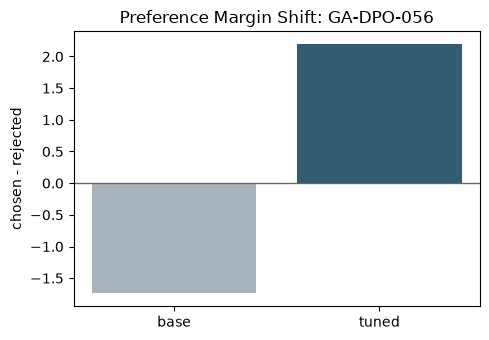

In [23]:
# Prefer a true flip because it is the clearest live-demo example.
flipped = comparison_all[
    (~comparison_all["prefers_chosen_base"]) & (comparison_all["prefers_chosen_tuned"])
].sort_values("margin_change", ascending=False)
if len(flipped):
    example_id = flipped.iloc[0]["id"]
else:
    example_id = comparison_all.sort_values("margin_change", ascending=False).iloc[0]["id"]

# Pull the original human-readable row so we can show the actual text, not just metrics.
example_source = source_df[source_df["id"] == example_id].iloc[0]
example_scores = comparison_all[comparison_all["id"] == example_id].iloc[0]

print("Concrete before/after example")
print(f"Example: {example_id} / {example_source['category']}")
print(f"Base margin:  {example_scores['margin_base']:.2f}")
print(f"Tuned margin: {example_scores['margin_tuned']:.2f}")
print(f"Change:       {example_scores['margin_change']:.2f}")
print("\nTASK")
print(example_source["prompt"])
print("\nON-BRAND CHOSEN")
print(example_source["chosen"])
print("\nOFF-BRAND REJECTED")
print(example_source["rejected"])

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["base", "tuned"], [example_scores["margin_base"], example_scores["margin_tuned"]], color=["#a9b3bb", "#315c72"])
ax.axhline(0, color="#666", linewidth=1)
ax.set_title(f"Preference Margin Shift: {example_id}")
ax.set_ylabel("chosen - rejected")
plt.tight_layout()
